In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/CRazorback/The-SUSTech-SYSU-dataset-for-automatically-segmenting-and-classifying-corneal-ulcers.git


fatal: destination path 'The-SUSTech-SYSU-dataset-for-automatically-segmenting-and-classifying-corneal-ulcers' already exists and is not an empty directory.


In [ ]:
%cd /content/The-SUSTech-SYSU-dataset-for-automatically-segmenting-and-classifying-corneal-ulcers


/content/The-SUSTech-SYSU-dataset-for-automatically-segmenting-and-classifying-corneal-ulcers


In [ ]:
!mkdir -p /content/drive/MyDrive/corneal_ulcer_dataset

In [ ]:
!cp -r corneaLabels corneaOverlay rawImages ulcerLabels ulcerOverlay "Category information.xlsx" /content/drive/MyDrive/corneal_ulcer_dataset/


In [ ]:
!ls /content/drive/MyDrive/corneal_ulcer_dataset

'Category information.xlsx'   ulcerLabels    X_val.npy	   Y_val.npy
 corneaLabels		      ulcerOverlay   X_val.npz	   Y_val.npz
 corneaOverlay		      X_train.npy    Y_train.npy
 rawImages		      X_train.npz    Y_train.npz


In [ ]:
import os
base_path = "/content/drive/MyDrive/corneal_ulcer_dataset"
for folder in os.listdir(base_path):
  folder_path = os.path.join(base_path,folder)
  if os.path.isdir(folder_path):
    print(f"{folder}: {len(os.listdir(folder_path))} files")

corneaLabels: 712 files
corneaOverlay: 712 files
rawImages: 712 files
ulcerLabels: 354 files
ulcerOverlay: 354 files


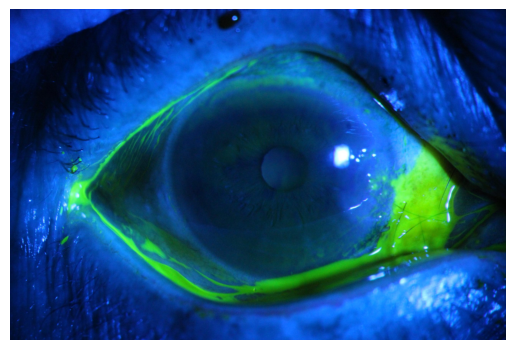

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(base_path,"rawImages",os.listdir(os.path.join(base_path,"rawImages"))[1])
img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

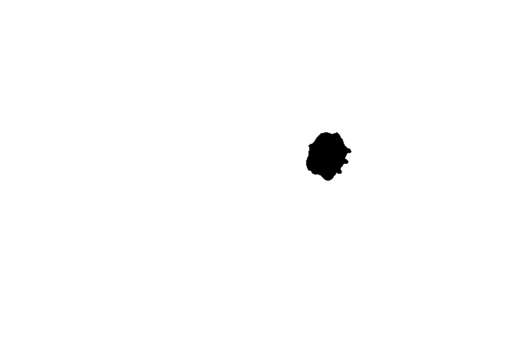

In [ ]:
img_path = os.path.join(base_path,"ulcerLabels",os.listdir(os.path.join(base_path,"ulcerLabels"))[1])
img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
#setting paths
raw_dir= os.path.join(base_path, "rawImages")
ulcer_labels_dir= os.path.join(base_path, "ulcerLabels")
cornea_labels_dir= os.path.join(base_path, "corneaLabels")

In [ ]:
raw_images=sorted(os.listdir(raw_dir))
ulcer_masks=sorted(os.listdir(ulcer_labels_dir))
cornea_masks=sorted(os.listdir(cornea_labels_dir))

print("Raw images:", raw_images[:5])
print("Ulcer masks:", ulcer_masks[:5])
print("Cornea masks:", cornea_masks[:5])

Raw images: ['1.jpg', '10.jpg', '100.jpg', '101.jpg', '102.jpg']
Ulcer masks: ['359.png', '360.png', '361.png', '362.png', '363.png']
Cornea masks: ['1.png', '10.png', '100.png', '101.png', '102.png']


In [ ]:
ulcer_ids=  [os.path.splitext(f)[0] for f in ulcer_masks]
print("Number of usable ulcer masks:",len(ulcer_ids))
print("First 10 usable IDs:",ulcer_ids[:10])

Number of usable ulcer masks: 354
First 10 usable IDs: ['359', '360', '361', '362', '363', '364', '365', '366', '367', '368']


In [ ]:
import pandas as pd
excel_file = "/content/drive/MyDrive/corneal_ulcer_dataset/Category information.xlsx"
df = pd.read_excel(excel_file)
print(df.head())
print(df.columns)

  Unnamed: 0  Category  Type  Grade
0      1.jpg         0     4      3
1      2.jpg         0     4      3
2      3.jpg         0     2      2
3      4.jpg         0     2      1
4      5.jpg         0     1      3
Index(['Unnamed: 0', 'Category', 'Type', 'Grade'], dtype='object')


In [ ]:
import os


#setting Paths
base_path= "/content/drive/MyDrive/corneal_ulcer_dataset"
raw_dir= os.path.join(base_path,"rawImages")
ulcer_labels_dir  =os.path.join(base_path,"ulcerLabels")
cornea_labels_dir= os.path.join(base_path,"corneaLabels")

# List of existing ulcer mask IDs
ulcer_masks= os.listdir(ulcer_labels_dir)
ulcer_ids =[os.path.splitext(f)[0] for f in ulcer_masks]

# Loading Excel
excel_file = os.path.join(base_path,"Category information.xlsx")
df = pd.read_excel(excel_file)
# Stripping '.jpg' from Excel IDs
df['ID_str'] = df['Unnamed: 0'].astype(str).str.replace('.jpg','')

#Filtering only Category 1 or 2 (point flaky or flaky ulcers): point like ulcers are too small for segmentation therefore category 0 is ommited
df_filtered = df[df['Category'].isin([1,2])]

#Keep only IDs that exist in ulcer masks
df_filtered = df_filtered[df_filtered['ID_str'].isin(ulcer_ids)]
print("Total filtered samples:", len(df_filtered))
print(df_filtered.head())


Total filtered samples: 354
    Unnamed: 0  Category  Type  Grade ID_str
358    359.jpg         1     4      4    359
359    360.jpg         1     4      4    360
360    361.jpg         1     4      4    361
361    362.jpg         1     4      4    362
362    363.jpg         1     4      2    363


In [ ]:
aligned_raw = [f"{sid}.jpg" for sid in df_filtered['ID_str']]
aligned_ulcer =[f"{sid}.png" for sid in df_filtered['ID_str']]
aligned_cornea = [f"{sid}.png" for sid in df_filtered['ID_str']]

#Verifying if  files exist
aligned_files = []
for r,u,c in zip(aligned_raw, aligned_ulcer, aligned_cornea):
  if os.path.exists(os.path.join(raw_dir, r)) and \
      os.path.exists(os.path.join(ulcer_labels_dir,u)) and \
      os.path.exists(os.path.join(cornea_labels_dir,c)):
      aligned_files.append((r, u, c))
print("Total aligned sets:", len(aligned_files))

Total aligned sets: 354


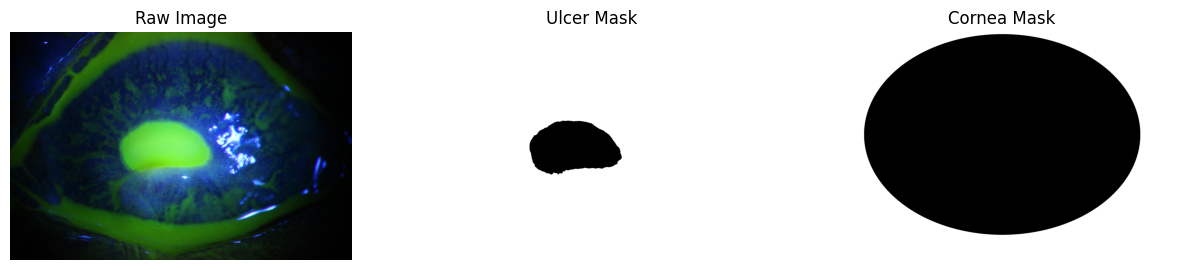

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

#Picking a sample from the aligned files
sample_idx = 0
raw_file,ulcer_file,cornea_file =aligned_files[sample_idx]

# Load images
raw_path = os.path.join(raw_dir, raw_file)
ulcer_path = os.path.join(ulcer_labels_dir, ulcer_file)
cornea_path = os.path.join(cornea_labels_dir, cornea_file)

raw_img = cv2.imread(raw_path)
# convert BGR to RGB
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
ulcer_mask = cv2.imread(ulcer_path, cv2.IMREAD_GRAYSCALE)
cornea_mask = cv2.imread(cornea_path, cv2.IMREAD_GRAYSCALE)

# Binarizing masks for better visualization
ulcer_mask = (ulcer_mask > 0).astype(int)
cornea_mask = (cornea_mask > 0).astype(int)

# Plotting side by side
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(raw_img)
plt.title("Raw Image")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(ulcer_mask, cmap='gray')
plt.title("Ulcer Mask")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(cornea_mask, cmap='gray')
plt.title("Cornea Mask")
plt.axis('off')

plt.show()


In [ ]:
IMG_SIZE = 256

def preprocess_image_mask(raw_path, ulcer_path, cornea_path):

  import cv2
  import numpy as np

  img = cv2.imread(raw_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

  ulcer_mask =cv2.imread(ulcer_path, cv2.IMREAD_GRAYSCALE)
  ulcer_mask =cv2.resize(ulcer_mask, (IMG_SIZE, IMG_SIZE))
  ulcer_mask =(ulcer_mask > 0).astype(np.uint8)
  cornea_mask= cv2.imread(cornea_path, cv2.IMREAD_GRAYSCALE)
  cornea_mask  = cv2.resize(cornea_mask, (IMG_SIZE, IMG_SIZE))
  cornea_mask= (cornea_mask > 0).astype(np.uint8)

  return img, ulcer_mask, cornea_mask

In [ ]:
def crop_to_cornea(img, ulcer_mask,cornea_mask):

  coords = cv2.findNonZero(cornea_mask)
  x, y, w, h = cv2.boundingRect(coords)

  img_crop = cv2.resize(img[y:y+h, x:x+w], (IMG_SIZE, IMG_SIZE))
  ulcer_crop = cv2.resize(ulcer_mask[y:y+h, x:x+w], (IMG_SIZE, IMG_SIZE))
  cornea_crop = cv2.resize(cornea_mask[y:y+h, x:x+w], (IMG_SIZE, IMG_SIZE))

  return img_crop, ulcer_crop, cornea_crop


In [ ]:
def load_and_preprocess_data(aligned_files,raw_dir,ulcer_labels_dir,  cornea_labels_dir):
  imgs, ulcer_masks, cornea_masks = [], [], []

  for (raw_name,ulcer_name,cornea_name) in aligned_files:

    raw_path = os.path.join(raw_dir, raw_name)
    ulcer_path = os.path.join(ulcer_labels_dir, ulcer_name)
    cornea_path = os.path.join(cornea_labels_dir, cornea_name)

    img, ulcer_mask, cornea_mask = preprocess_image_mask(raw_path, ulcer_path, cornea_path)
    img_crop, ulcer_crop, cornea_crop = crop_to_cornea(img, ulcer_mask, cornea_mask)
    imgs.append(img_crop)
    ulcer_masks.append(ulcer_crop)
    cornea_masks.append(cornea_crop)

#converted resulting images into numpy arrays
  imgs = np.array(imgs)
  ulcer_masks = np.array(ulcer_masks)
  cornea_masks = np.array(cornea_masks)

  print(f"Loaded {len(imgs)} samples.")
  return imgs, ulcer_masks, cornea_masks

In [ ]:
#spliitng the dataset into 80%  training and 10 validationa and test set 10
def split_dataset(images, ulcer_masks, cornea_masks, test_size=0.2, val_size=0.1, random_state=42):

  X_train,X_temp,ulcer_train,  ulcer_temp,cornea_train,cornea_temp = train_test_split(images, ulcer_masks, cornea_masks,test_size=(test_size+val_size),random_state=random_state)
  val_ratio = val_size / (test_size + val_size)
  X_val, X_test, ulcer_val, ulcer_test, cornea_val, cornea_test = train_test_split(
      X_temp,ulcer_temp, cornea_temp,
      test_size=(1-val_ratio),
      random_state=random_state
    )
  print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
  return (X_train, ulcer_train, cornea_train), (X_val, ulcer_val, cornea_val), (X_test, ulcer_test, cornea_test)


In [ ]:
!pip install tensorflow
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def get_augment_generators(X_train, ulcer_train, batch_size=8):
  data_gen_args = dict(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

#This generator generates augmneted images on the fly for both images and mask pairs
  image_datagen= ImageDataGenerator(**data_gen_args)
  mask_datagen= ImageDataGenerator(**data_gen_args)
  image_generator= image_datagen.flow(X_train, batch_size=batch_size, seed=42)
  ulcer_generator= mask_datagen.flow(ulcer_train[..., np.newaxis], batch_size=batch_size, seed=42)

  train_generator= zip(image_generator, ulcer_generator)
  return train_generator


In [ ]:
images, ulcer_masks, cornea_masks = load_and_preprocess_data(
    aligned_files, raw_dir, ulcer_labels_dir, cornea_labels_dir
)(train_images, train_ulcer, train_cornea), \(val_images, val_ulcer, val_cornea), \(test_images, test_ulcer, test_cornea) = split_dataset(images, ulcer_masks, cornea_masks)
train_gen = get_augment_generators(train_images, train_ulcer, batch_size=8)

Loaded 354 samples.
Train: 247, Val: 35, Test: 72


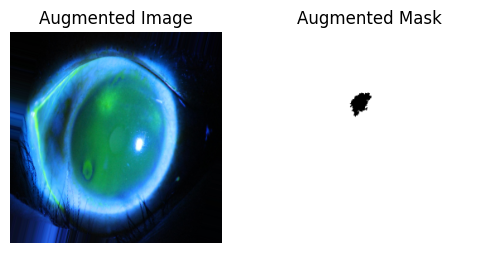

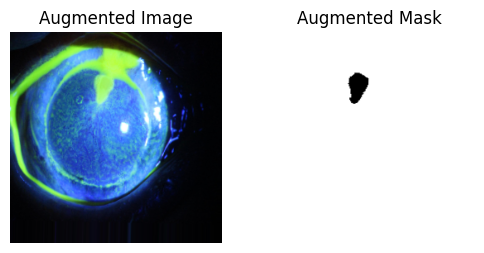

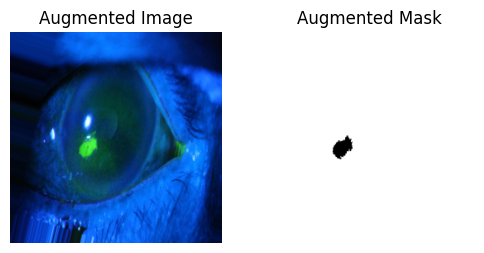

In [ ]:
images_aug, masks_aug = next(train_gen)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(images_aug[i])
    plt.title("Augmented Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(masks_aug[i].squeeze(), cmap='gray')
    plt.title("Augmented Mask")
    plt.axis("off")
    plt.show()

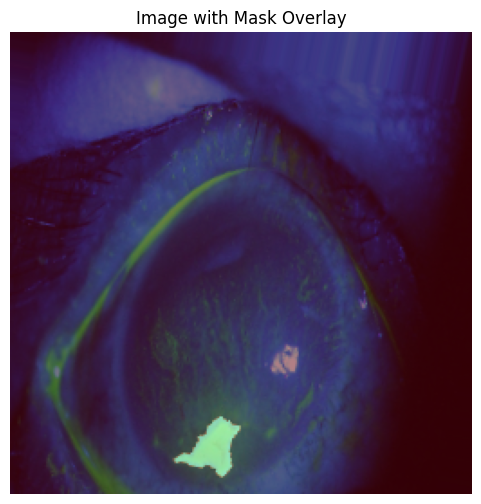

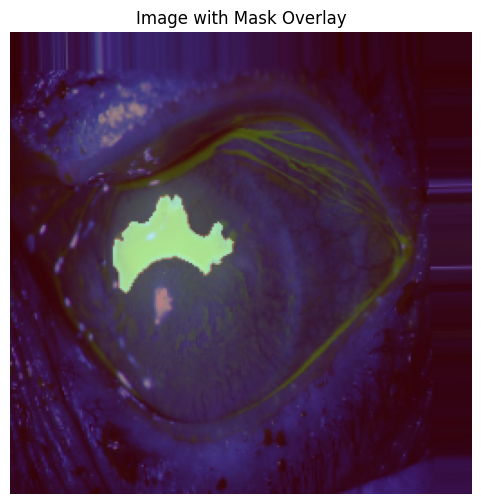

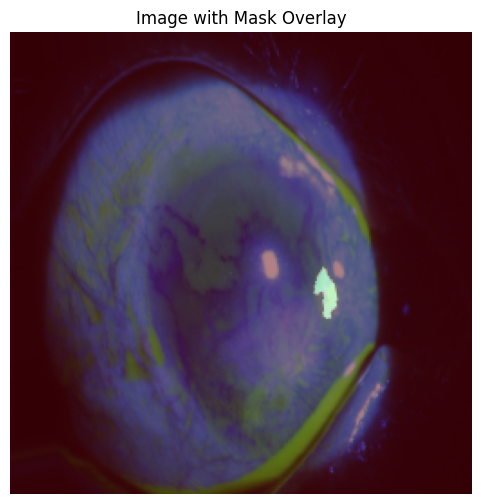

In [ ]:
images_aug, masks_aug = next(train_gen)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(6,6))
    plt.imshow(images_aug[i]) #the RGB image
    plt.imshow(masks_aug[i].squeeze(), cmap='Reds', alpha=0.5)  #overlaying mask in  red semi transparent
    plt.title("Image with Mask Overlay")
    plt.axis("off")
    plt.show()


In [ ]:
import numpy as np

# Saving preprocessed datasets
np.save("train_images.npy", train_images)
np.save("train_ulcer.npy", train_ulcer)
np.save("train_cornea.npy", train_cornea)

np.save("val_images.npy", val_images)
np.save("val_ulcer.npy", val_ulcer)
np.save("val_cornea.npy", val_cornea)

np.save("test_images.npy", test_images)
np.save("test_ulcer.npy", test_ulcer)
np.save("test_cornea.npy", test_cornea)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#saving the path for future access
saving_path = "/content/drive/MyDrive/corneal_ulcer_dataset/"

np.save(saving_path + "train_images.npy", train_images)
np.save(saving_path + "train_ulcer.npy", train_ulcer)
np.save(saving_path + "train_cornea.npy", train_cornea)

np.save(saving_path + "val_images.npy", val_images)
np.save(saving_path + "val_ulcer.npy", val_ulcer)
np.save(saving_path + "val_cornea.npy", val_cornea)

np.save(saving_path + "test_images.npy", test_images)
np.save(saving_path + "test_ulcer.npy", test_ulcer)
np.save(saving_path + "test_cornea.npy", test_cornea)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
